# Optimization Methods, Seminar 01: verification notebook


## 1. Setup


In [ ]:
from __future__ import annotations

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

x1, x2, x3, a, r, phi, alpha = sp.symbols("x1 x2 x3 a r phi alpha", real=True)
XY = (x1, x2)
XYZ = (x1, x2, x3)

CHECKS: list[dict] = []


def grad(expr: sp.Expr, variables: tuple = XY) -> sp.Matrix:
    return sp.Matrix([sp.diff(expr, v) for v in variables])


def hess(expr: sp.Expr, variables: tuple = XY) -> sp.Matrix:
    return sp.hessian(expr, variables)


def leading_minors(M: sp.Matrix) -> list:
    return [sp.simplify(M[:k, :k].det()) for k in range(1, M.rows + 1)]


def principal_minors(M: sp.Matrix) -> list:
    from itertools import combinations

    out = []
    for k in range(1, M.rows + 1):
        for idx in combinations(range(M.rows), k):
            out.append(sp.simplify(M[idx, idx].det()))
    return out


def definiteness(M: sp.Matrix) -> str:
    vals = [float(sp.re(sp.N(e))) for e in M.eigenvals()]
    tol = 1e-12 * max(1.0, max(abs(v) for v in vals))
    if all(abs(v) <= tol for v in vals):
        return "zero matrix: both semidefinite"
    if all(v > tol for v in vals):
        return "positive definite"
    if all(v < -tol for v in vals):
        return "negative definite"
    if all(v >= -tol for v in vals):
        return "positive semidefinite"
    if all(v <= tol for v in vals):
        return "negative semidefinite"
    return "indefinite"


def stationary_points(expr: sp.Expr, variables: tuple = XY) -> list:
    sols = sp.solve(list(grad(expr, variables)), list(variables), dict=True)
    return [tuple(s.get(v, v) for v in variables) for s in sols]


def check(label: str, computed, expected) -> None:
    same = (
        sp.simplify(sp.Matrix(computed) - sp.Matrix(expected)).is_zero_matrix
        if isinstance(computed, (sp.Matrix, list))
        else sp.simplify(computed - expected) == 0
    )
    CHECKS.append(
        {
            "check": label,
            "in materials": str(expected),
            "computed": str(computed),
            "match": bool(same),
        }
    )
    assert same, f"{label}: materials say {expected}, computed {computed}"


def show(section: str) -> pd.DataFrame:
    df = pd.DataFrame(CHECKS)
    CHECKS.clear()
    df.insert(0, "section", section)
    return df


print("numpy", np.__version__, "| sympy", sp.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | sympy 1.14.0 | pandas 3.0.5


## 2. Exercises 1–3: gradients, Hessians, Sylvester

The expected values in each `check` call are taken from slides 8, 10 and 12


In [ ]:
# --- lecture example: det H(1,1) = 200
f_lect = 3 * x1**3 + 2 * x1 * x2**2 + 4 * x2**2
H_lect = hess(f_lect)
check("lecture: H(1,1)", H_lect.subs({x1: 1, x2: 1}), sp.Matrix([[18, 4], [4, 12]]))
check("lecture: det H(1,1)", H_lect.subs({x1: 1, x2: 1}).det(), 200)

# --- Exercise 1
f1 = x1**2 + x2**2 - x1 * x2
check("exercise 1: grad", grad(f1), sp.Matrix([2 * x1 - x2, 2 * x2 - x1]))
check("exercise 1: H", hess(f1), sp.Matrix([[2, -1], [-1, 2]]))
check("exercise 1: grad(1,1)", grad(f1).subs({x1: 1, x2: 1}), sp.Matrix([1, 1]))
eig1 = sorted(float(sp.N(e)) for e in hess(f1).eigenvals())
assert np.allclose(eig1, [1.0, 3.0]), eig1

# --- Exercise 2 (same function as the lecture example, different point)
check(
    "exercise 2: grad(2,-1)", grad(f_lect).subs({x1: 2, x2: -1}), sp.Matrix([38, -16])
)
check(
    "exercise 2: H(2,-1)", H_lect.subs({x1: 2, x2: -1}), sp.Matrix([[36, -4], [-4, 16]])
)
check("exercise 2: det H(2,-1)", H_lect.subs({x1: 2, x2: -1}).det(), 560)

# --- Exercise 3
f3 = x1**2 + 2 * x2**2 + 3 * x3**2 + 2 * x1 * x2 - x2 * x3
H3 = hess(f3, XYZ)
check("exercise 3: H", H3, sp.Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]]))
D1, D2, D3 = leading_minors(H3)
check("exercise 3: D1", D1, 2)
check("exercise 3: D2", D2, 4)
check("exercise 3: D3", D3, 22)
assert definiteness(H3) == "positive definite"
assert stationary_points(f3, XYZ) == [(0, 0, 0)]

show("block 1")

,section,check,in materials,computed,match
0,block 1,"lecture: H(1,1)","Matrix([[18, 4], [4, 12]])","Matrix([[18, 4], [4, 12]])",True
1,block 1,"lecture: det H(1,1)",200,200,True
2,block 1,exercise 1: grad,"Matrix([[2*x1 - x2], [-x1 + 2*x2]])","Matrix([[2*x1 - x2], [-x1 + 2*x2]])",True
3,block 1,exercise 1: H,"Matrix([[2, -1], [-1, 2]])","Matrix([[2, -1], [-1, 2]])",True
4,block 1,"exercise 1: grad(1,1)","Matrix([[1], [1]])","Matrix([[1], [1]])",True
5,block 1,"exercise 2: grad(2,-1)","Matrix([[38], [-16]])","Matrix([[38], [-16]])",True
6,block 1,"exercise 2: H(2,-1)","Matrix([[36, -4], [-4, 16]])","Matrix([[36, -4], [-4, 16]])",True
7,block 1,"exercise 2: det H(2,-1)",560,560,True
8,block 1,exercise 3: H,"Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]])","Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]])",True
9,block 1,exercise 3: D1,2,2,True


Slide 11 has a hint about cross terms: a term $c\,x_ix_j$ puts $c$ into the off-diagonal entries of the Hessian. The halved value $c/2$ belongs to the matrix $A$ in the form $f=x^{\top}Ax$


In [ ]:
c = sp.symbols("c", real=True)
f_cross = c * x1 * x2

H_cross = hess(f_cross)
A_form = sp.Matrix([[0, c / 2], [c / 2, 0]])

assert H_cross == sp.Matrix([[0, c], [c, 0]])
assert (
    sp.simplify((sp.Matrix([x1, x2]).T * A_form * sp.Matrix([x1, x2]))[0] - f_cross)
    == 0
)
assert H_cross == A_form + A_form.T

pd.DataFrame(
    [
        {"form": "H (Hessian)", "off-diagonal entry": "c", "verified": True},
        {
            "form": "A in f = x^T A x",
            "off-diagonal entry": "c/2",
            "verified": True,
        },
    ]
)

,form,off-diagonal entry,verified
0,H (Hessian),c,True
1,A in f = x^T A x,c/2,True


## 3. Exercises 4–7: stationary points and their classification

`definiteness` computes the eigenvalues exactly, and its output is the reference for checking the result of Sylvester's criterion


In [ ]:
f4 = x1**2 + x2**2
f5 = x1**2 - x2**2
f6 = x1**3 - 3 * x1 * x2**2
f7 = x1**4 + x2**4

rows = []
for name, f in [
    ("4: x1^2+x2^2", f4),
    ("5: x1^2-x2^2", f5),
    ("6: x1^3-3x1x2^2", f6),
    ("7: x1^4+x2^4", f7),
]:
    pts = stationary_points(f)
    H0 = hess(f).subs({x1: 0, x2: 0})
    rows.append(
        {
            "exercise": name,
            "stationary points": str(pts),
            "H(0,0)": str(H0.tolist()),
            "definiteness": definiteness(H0),
            "leading minors": str(leading_minors(H0)),
        }
    )

assert (
    stationary_points(f4) == [(0, 0)] and definiteness(hess(f4)) == "positive definite"
)
assert definiteness(hess(f5)) == "indefinite"
assert stationary_points(f6) == [(0, 0)]
assert hess(f6).subs({x1: 0, x2: 0}) == sp.zeros(2, 2)
assert hess(f7).subs({x1: 0, x2: 0}) == sp.zeros(2, 2)

pd.DataFrame(rows)

,exercise,stationary points,"H(0,0)",definiteness,leading minors
0,4: x1^2+x2^2,"[(0, 0)]","[[2, 0], [0, 2]]",positive definite,"[2, 4]"
1,5: x1^2-x2^2,"[(0, 0)]","[[2, 0], [0, -2]]",indefinite,"[2, -4]"
2,6: x1^3-3x1x2^2,"[(0, 0)]","[[0, 0], [0, 0]]",zero matrix: both semidefinite,"[0, 0]"
3,7: x1^4+x2^4,"[(0, 0)]","[[0, 0], [0, 0]]",zero matrix: both semidefinite,"[0, 0]"


Exercise 5 is proved with two one-dimensional restrictions of $f$, and the plot only illustrates the result. Exercise 6 uses the same argument, but the restriction has to be found by hand because the second-order test is inconclusive there


In [ ]:
# exercise 5: restrictions to the axes
assert sp.simplify(f5.subs(x2, 0) - x1**2) == 0
assert sp.simplify(f5.subs(x1, 0) + x2**2) == 0

# exercise 6: the restriction to the line x2 = 0 changes sign
restr = sp.simplify(f6.subs(x2, 0))
assert restr == x1**3
assert (
    restr.subs(x1, sp.Rational(1, 10)) > 0 and restr.subs(x1, sp.Rational(-1, 10)) < 0
)

# exercise 6 in polar coordinates: f = r^3 cos(3 phi) -> six sectors
polar = sp.simplify(f6.subs({x1: r * sp.cos(phi), x2: r * sp.sin(phi)}))
assert sp.simplify(polar - r**3 * sp.cos(3 * phi)) == 0

# sector midpoints: phi_k = k * 60 degrees, where cos(3*phi_k) = (-1)^k
signs = [sp.cos(3 * sp.pi * k / 3) for k in range(6)]
assert signs == [sp.Integer((-1) ** k) for k in range(6)]
print("f = r^3 * cos(3*phi), sign at the midpoints of the six sectors:")
print(", ".join(f"{60 * k}deg: {'+' if v > 0 else '-'}" for k, v in enumerate(signs)))

# exercise 7: f >= 0 with equality only at the origin
assert sp.simplify(f7) == f7 and f7.subs({x1: 0, x2: 0}) == 0
assert all(f7.subs({x1: p, x2: q}) > 0 for p, q in [(0.1, 0), (0, -0.1), (0.05, 0.05)])
print("\nexercise 7: f(x) > 0 at all nonzero test points")

f = r^3 * cos(3*phi), sign at the midpoints of the six sectors:
0deg: +, 60deg: -, 120deg: +, 180deg: -, 240deg: +, 300deg: -

exercise 7: f(x) > 0 at all nonzero test points


## 4. Sylvester's criterion for semidefinite matrices (slide 13)

The two matrices below have the same leading minors, but one is positive semidefinite and the other is negative semidefinite. Leading minors alone cannot decide semidefiniteness, and the correct test uses all principal minors


In [ ]:
A_neg = sp.Matrix([[0, 0], [0, -1]])
A_pos = sp.Matrix([[0, 0], [0, 1]])

assert leading_minors(A_neg) == leading_minors(A_pos) == [0, 0]
assert definiteness(A_neg) == "negative semidefinite"
assert definiteness(A_pos) == "positive semidefinite"

pd.DataFrame(
    [
        {
            "matrix": "diag(0, -1)",
            "leading minors": str(leading_minors(A_neg)),
            "all principal minors": str(principal_minors(A_neg)),
            "truth": definiteness(A_neg),
        },
        {
            "matrix": "diag(0, +1)",
            "leading minors": str(leading_minors(A_pos)),
            "all principal minors": str(principal_minors(A_pos)),
            "truth": definiteness(A_pos),
        },
    ]
)

,matrix,leading minors,all principal minors,truth
0,"diag(0, -1)","[0, 0]","[0, -1, 0]",negative semidefinite
1,"diag(0, +1)","[0, 0]","[0, 1, 0]",positive semidefinite


A $3\times3$ matrix has 3 leading minors and 7 principal minors. A correct semidefiniteness check by hand needs all seven, so in code it is simpler to compute the eigenvalues


In [ ]:
M = sp.Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]])
print(
    "leading minors:",
    len(leading_minors(M)),
    "| all principal minors:",
    len(principal_minors(M)),
)
print("values of all principal minors:", principal_minors(M))
assert len(principal_minors(M)) == 7

leading minors: 3 | all principal minors: 7
values of all principal minors: [2, 4, 6, 4, 12, 23, 22]


## 5. The zero-Hessian pair

Slide 19 states that $x_1^4+x_2^4$ and $x_1^3-3x_1x_2^2$ have the same first- and second-order data at the origin, yet the first has a strict minimum there and the second has no extremum. So no test that uses only $\nabla f(0)$ and $H(0)$ can tell them apart. The cell below checks this directly


In [ ]:
data = []
for name, f in [("x1^4 + x2^4", f7), ("x1^3 - 3x1x2^2", f6)]:
    g0 = grad(f).subs({x1: 0, x2: 0})
    H0 = hess(f).subs({x1: 0, x2: 0})
    ts = np.linspace(0, 2 * np.pi, 721)
    fn = sp.lambdify(XY, f, "numpy")
    vals = fn(0.01 * np.cos(ts), 0.01 * np.sin(ts))
    data.append(
        {
            "function": name,
            "grad(0)": str(list(g0)),
            "H(0)": str(H0.tolist()),
            "min f on circle": f"{vals.min():.2e}",
            "max f on circle": f"{vals.max():.2e}",
            "verdict": "strict minimum" if vals.min() > 0 else "no extremum",
        }
    )

assert grad(f6).subs({x1: 0, x2: 0}) == grad(f7).subs({x1: 0, x2: 0})
assert hess(f6).subs({x1: 0, x2: 0}) == hess(f7).subs({x1: 0, x2: 0})
pd.DataFrame(data)

,function,grad(0),H(0),min f on circle,max f on circle,verdict
0,x1^4 + x2^4,"[0, 0]","[[0, 0], [0, 0]]",5.00e-09,1.00e-08,strict minimum
1,x1^3 - 3x1x2^2,"[0, 0]","[[0, 0], [0, 0]]",-1.00e-06,1.00e-06,no extremum


## 6. Exercises 8–9: convexity

Exercise 8 is proved with the triangle inequality, and the cell below gives a numerical illustration. Exercise 9 and the family $x_1^2+x_2^2+a\,x_1x_2$ are checked symbolically


In [ ]:
rng = np.random.default_rng(42)

# exercise 8: the radius-2 disk is convex; 100000 random convex combinations stay inside
P = rng.normal(size=(100_000, 2))
P = P / np.linalg.norm(P, axis=1, keepdims=True) * rng.uniform(0, 2, size=(100_000, 1))
Q = rng.normal(size=(100_000, 2))
Q = Q / np.linalg.norm(Q, axis=1, keepdims=True) * rng.uniform(0, 2, size=(100_000, 1))
lam = rng.uniform(0, 1, size=(100_000, 1))
Z = lam * P + (1 - lam) * Q
assert np.all(np.linalg.norm(Z, axis=1) <= 2 + 1e-12)
print(
    f"exercise 8: max norm of a combination {np.linalg.norm(Z, axis=1).max():.6f} <= 2"
)

# exercise 9 and the family parametrized by a
f9 = x1**2 + x2**2 - 4 * x1 * x2
H9 = hess(f9)
check("exercise 9: H", H9, sp.Matrix([[2, -4], [-4, 2]]))
assert np.allclose(sorted(float(sp.N(e)) for e in H9.eigenvals()), [-2.0, 6.0])
assert definiteness(H9) == "indefinite"

H_a = hess(x1**2 + x2**2 + a * x1 * x2)
eigs_a = sorted(H_a.eigenvals(), key=str)
print("eigenvalues of the family:", eigs_a, "-> convex for |a| <= 2")
assert set(eigs_a) == {2 - a, a + 2}

show("block 3")

exercise 8: max norm of a combination 1.996681 <= 2
eigenvalues of the family: [2 - a, a + 2] -> convex for |a| <= 2


,section,check,in materials,computed,match
0,block 3,exercise 9: H,"Matrix([[2, -4], [-4, 2]])","Matrix([[2, -4], [-4, 2]])",True


## 7. Exercises 10–11: feasible directions and directional derivatives

Exercise 10 is checked by going through a list of directions and looking for a feasible $s$ with $s^{\top}\nabla f<0$. Exercise 11 is computed in two ways: as a limit from the definition and with the gradient formula


In [ ]:
def is_feasible_first_quadrant(
    point: np.ndarray, s: np.ndarray, alphas: np.ndarray | None = None
) -> bool:
    if alphas is None:
        alphas = np.linspace(0, 1e-3, 50)
    pts = point[None, :] + alphas[:, None] * s[None, :]
    return bool(np.all(pts >= -1e-12))


x_star = np.array([0.0, 2.0])
grad_f = np.array([1.0, 1.0])  # f = x1 + x2

directions = {
    "(1, 0)": np.array([1.0, 0.0]),
    "(0, 1)": np.array([0.0, 1.0]),
    "(0, -1)": np.array([0.0, -1.0]),
    "(-1, 0)": np.array([-1.0, 0.0]),
    "(1, -1)": np.array([1.0, -1.0]),
}

rows = [
    {
        "direction": k,
        "feasible": is_feasible_first_quadrant(x_star, s),
        "s^T grad f": float(s @ grad_f),
        "violates condition": is_feasible_first_quadrant(x_star, s)
        and float(s @ grad_f) < 0,
    }
    for k, s in directions.items()
]
df10 = pd.DataFrame(rows)

violating = df10.loc[df10["violates condition"], "direction"].tolist()
assert "(0, -1)" in violating and "(-1, 0)" not in violating
print("feasible directions that violate the first-order condition:", violating)
df10

feasible directions that violate the first-order condition: ['(0, -1)']


,direction,feasible,s^T grad f,violates condition
0,"(1, 0)",True,1.0,False
1,"(0, 1)",True,1.0,False
2,"(0, -1)",True,-1.0,True
3,"(-1, 0)",False,-1.0,False
4,"(1, -1)",True,0.0,False


In [ ]:
# exercise 11: the directional derivative computed in two ways
f11 = x1**2 + 2 * x2**2
point, s_dir = (1, 1), sp.Matrix([1, -1])

along = sp.expand(f11.subs({x1: 1 + alpha * s_dir[0], x2: 1 + alpha * s_dir[1]}))
by_definition = sp.limit((along - along.subs(alpha, 0)) / alpha, alpha, 0)
by_formula = (s_dir.T * grad(f11).subs({x1: point[0], x2: point[1]}))[0]

check("exercise 11: by definition", by_definition, -2)
check("exercise 11: by formula", by_formula, -2)
assert sp.simplify(along - (3 - 2 * alpha + 3 * alpha**2)) == 0

per_unit_length = by_formula / s_dir.norm()
steepest = -grad(f11).subs({x1: point[0], x2: point[1]}).norm()
print(
    f"along s: {by_formula} per unit of alpha, {sp.nsimplify(per_unit_length)} per unit length"
)
print(
    f"steepest descent at (1,1): {sp.nsimplify(steepest)} = {float(steepest):.4f} per unit length"
)
assert sp.simplify(per_unit_length + sp.sqrt(2)) == 0
show("block 4")

along s: -2 per unit of alpha, -sqrt(2) per unit length
steepest descent at (1,1): -2*sqrt(5) = -4.4721 per unit length


,section,check,in materials,computed,match
0,block 4,exercise 11: by definition,-2,-2,True
1,block 4,exercise 11: by formula,-2,-2,True


## 8. Reference code for the students (home practice 4)

The two functions printed on slide 25, with tests. `classify` returns `"inconclusive"` when the second-order test gives no answer, and the exercise is built around these cases


In [ ]:
def central_diff(f, x, h: float = 1e-5) -> np.ndarray:
    """Gradient by central differences: an independent check of an analytic formula"""
    x = np.asarray(x, dtype=float)
    g = np.empty_like(x)
    for j in range(x.size):
        e = np.zeros_like(x)
        e[j] = h
        g[j] = (f(x + e) - f(x - e)) / (2 * h)
    return g


def classify(H: np.ndarray, tol: float = 1e-8) -> str:
    """Second-order test with an explicit tolerance"""
    w = np.linalg.eigvalsh(0.5 * (H + H.T))
    if np.all(w > tol):
        return "min"
    if np.all(w < -tol):
        return "max"
    if w.min() < -tol < w.max():
        return "saddle"
    return "inconclusive"


functions = {
    "x1^2+x2^2": f4,
    "x1^2-x2^2": f5,
    "x1^3-3x1x2^2": f6,
    "x1^4+x2^4": f7,
    "x1^2+2x2^2": x1**2 + 2 * x2**2,
}
truth = {
    "x1^2+x2^2": "min",
    "x1^2-x2^2": "saddle",
    "x1^3-3x1x2^2": "no extremum",
    "x1^4+x2^4": "strict minimum",
    "x1^2+2x2^2": "min",
}

rows = []
for name, f in functions.items():
    f_num = sp.lambdify(XY, f, "numpy")
    g_num = sp.lambdify(XY, list(grad(f)), "numpy")
    H_num = np.array(hess(f).subs({x1: 0, x2: 0}), dtype=float)
    probe = np.array([0.3, -0.2])
    fd = central_diff(lambda v: float(f_num(*v)), probe)
    an = np.array(g_num(*probe), dtype=float)
    rows.append(
        {
            "function": name,
            "classify(H(0,0))": classify(H_num),
            "truth": truth[name],
            "|grad - finite diff|": f"{np.max(np.abs(fd - an)):.2e}",
        }
    )
    assert np.max(np.abs(fd - an)) < 1e-6

pd.DataFrame(rows)

,function,"classify(H(0,0))",truth,|grad - finite diff|
0,x1^2+x2^2,min,min,6.00e-13
1,x1^2-x2^2,saddle,saddle,6.00e-13
2,x1^3-3x1x2^2,inconclusive,no extremum,1.00e-10
3,x1^4+x2^4,inconclusive,strict minimum,1.20e-10
4,x1^2+2x2^2,min,min,8.00e-13


Two rows of the table are worth discussing: `x1^4+x2^4` and `x1^3-3x1x2^2` both get `"inconclusive"`, although the first has a strict minimum at the origin and the second has no extremum. This answers the question on slide 25: both functions have the same gradient and Hessian at the origin, so the limitation comes from the second-order test itself and no implementation of `classify` can separate them


## 9. Home practice: answers verified

The cell below checks the answers given in section 6 of the theory notes


In [ ]:
# 1) f = x1^3 + x2^2: the Hessian is semidefinite, but there is no extremum
f_hw = x1**3 + x2**2
H_hw = hess(f_hw).subs({x1: 0, x2: 0})
assert stationary_points(f_hw) == [(0, 0)]
assert (
    H_hw == sp.Matrix([[0, 0], [0, 2]])
    and definiteness(H_hw) == "positive semidefinite"
)
assert definiteness(sp.zeros(2, 2)) == "zero matrix: both semidefinite"
assert sp.simplify(f_hw.subs(x2, 0) - x1**3) == 0  # changes sign -> not a minimum

# 2) convexity of the family: |a| <= 2
convex_a = sp.solve([sp.Ge(2 - a, 0), sp.Ge(2 + a, 0)], a)
print("the family is convex for:", convex_a)

# 3) feasible directions at (0,0) for the first quadrant
origin = np.array([0.0, 0.0])
cone = {k: is_feasible_first_quadrant(origin, s) for k, s in directions.items()}
assert cone["(1, 0)"] and cone["(0, 1)"] and not cone["(0, -1)"] and not cone["(-1, 0)"]

pd.DataFrame(
    [
        {
            "exercise": "1) x1^3+x2^2",
            "answer": "H(0) is semidefinite, but the point is not an extremum",
            "verified": True,
        },
        {
            "exercise": "2) convexity in a",
            "answer": "|a| <= 2 (strictly convex for |a| < 2)",
            "verified": True,
        },
        {
            "exercise": "3) cone at (0,0)",
            "answer": "s1 >= 0 and s2 >= 0",
            "verified": True,
        },
        {
            "exercise": "4) classify",
            "answer": "inconclusive twice, as expected",
            "verified": True,
        },
    ]
)

the family is convex for: (-2 <= a) & (a <= 2)


,exercise,answer,verified
0,1) x1^3+x2^2,"H(0) is semidefinite, but the point is not an ...",True
1,2) convexity in a,|a| <= 2 (strictly convex for |a| < 2),True
2,"3) cone at (0,0)",s1 >= 0 and s2 >= 0,True
3,4) classify,"inconclusive twice, as expected",True


## 10. Landscape plots for live demonstration

The slides draw these landscapes in TikZ. The matplotlib versions below are for class, when you want to change parameters or show a surface from another angle


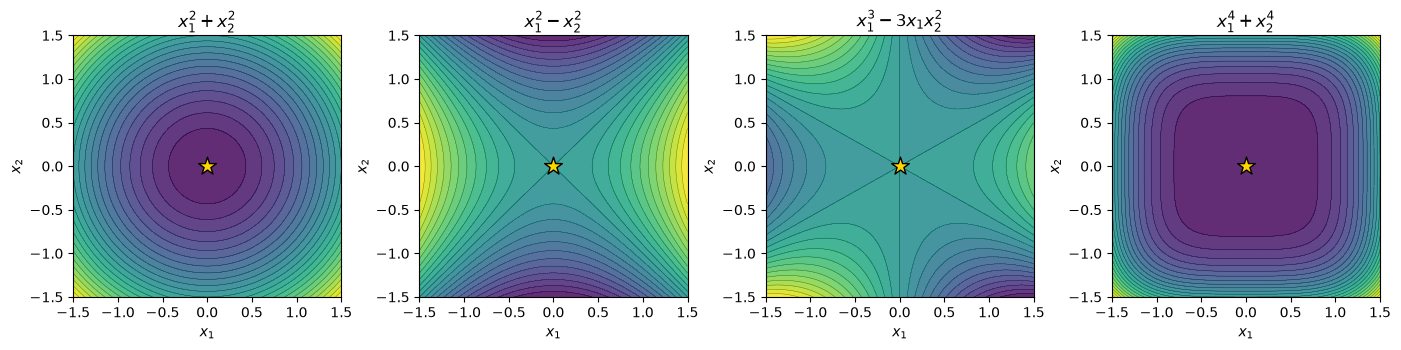

In [ ]:
grid = np.linspace(-1.5, 1.5, 200)
GX, GY = np.meshgrid(grid, grid)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (name, f) in zip(
    axes,
    [
        ("$x_1^2+x_2^2$", f4),
        ("$x_1^2-x_2^2$", f5),
        ("$x_1^3-3x_1x_2^2$", f6),
        ("$x_1^4+x_2^4$", f7),
    ],
):
    Z = sp.lambdify(XY, f, "numpy")(GX, GY)
    levels = np.linspace(Z.min(), Z.max(), 25)
    ax.contourf(GX, GY, Z, levels=levels, cmap="viridis", alpha=0.85)
    ax.contour(GX, GY, Z, levels=levels, colors="k", linewidths=0.3, alpha=0.5)
    ax.scatter([0], [0], marker="*", s=180, color="gold", edgecolor="k", zorder=5)
    ax.set_title(name)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

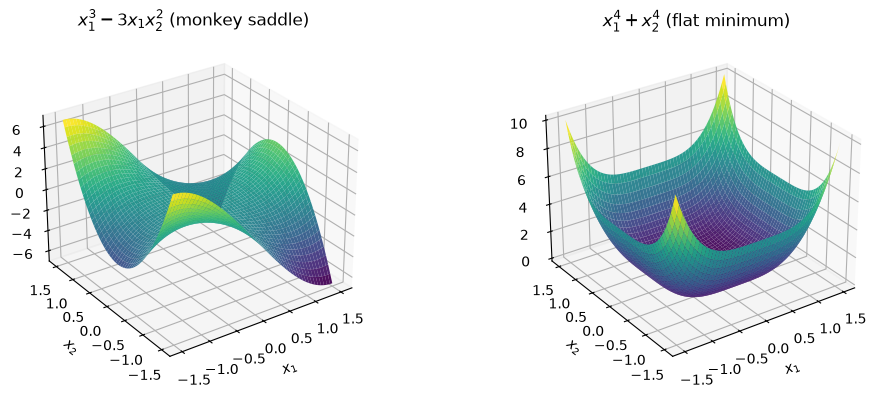

In [ ]:
fig = plt.figure(figsize=(11, 4))
for i, (name, f) in enumerate(
    [("$x_1^3-3x_1x_2^2$ (monkey saddle)", f6), ("$x_1^4+x_2^4$ (flat minimum)", f7)],
    start=1,
):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    Z = sp.lambdify(XY, f, "numpy")(GX, GY)
    ax.plot_surface(
        GX, GY, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95
    )
    ax.set_title(name)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.view_init(elev=28, azim=-125)
fig.tight_layout()
plt.show()

## Summary

If the cells above run without an `AssertionError`, every number in the slides, the talk script and the notes is reproduced by an independent computation: the determinants 200 and 560, the minors 2, 4 and 22, the eigenvalues $1, 3$ and $-2, 6$, the identity $x_1^3-3x_1x_2^2=r^3\cos 3\varphi$, the directional derivative $-2$ and the convexity bound $|a|\le 2$
